# Text Analytics Coursework (Group 37 - Task 2)



# Axis 1-B: LLM-Based Approach (Fine-tuned BERT): 
##### Instead of a general LLM, use a Fine-tuned BioBERT or PubMedBERT LLM Model.


Since the current `gold_label` distribution includes a high proportion of `NONE` and `MIXED` labels, for LLM-Based Approach, we restrict the dataset to unambiguous P/I/O only sentences for the initial experiments. This supports a fair comparison across model axes by reducing label ambiguity that could otherwise blur the distinction between P, I, and O.


In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
sentence_records_df = pd.read_csv("../outputs/sentence_records_df.csv")
sentence_test_records_df = pd.read_csv("../outputs/sentence_test_records_df.csv")

In [94]:
train_pio = sentence_records_df[sentence_records_df["gold_label"].isin(["P","I","O"])].copy()
test_pio  = sentence_test_records_df[sentence_test_records_df["gold_label"].isin(["P","I","O"])].copy()

print(f"Train_PIO_Label_Count: {train_pio["gold_label"].value_counts()}\n")
print(f"Test_PIO_Label_Count: {test_pio["gold_label"].value_counts()}")

Train_PIO_Label_Count: gold_label
O    10669
I     5966
P     2824
Name: count, dtype: int64

Test_PIO_Label_Count: gold_label
O    431
I    289
P    126
Name: count, dtype: int64


In [95]:
train_texts = train_pio["sentence_text"].tolist().copy()
train_labels = train_pio["gold_label"].tolist().copy()

test_texts = test_pio["sentence_text"].tolist().copy()
test_labels = test_pio["gold_label"].tolist().copy()

In [96]:
train_texts[:5]

['The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group).',
 'The ranitidine group received RNT 300 mg, CAM 400 mg, MTZ 500 mg (RCM group).',
 'Pre-operative short-term pulmonary rehabilitation for patients of chronic obstructive pulmonary disease undergoing coronary artery bypass graft surgery.',
 'The role of pre-operative short-term pulmonary rehabilitation in patients with chronic obstructive pulmonary disease who undergo coronary artery bypass graft surgery has been assessed for the first time prospectively.',
 'Pre-operative and post-operative peak expiratory flow rate, inspiratory capacity, post-operative ventilation time, post-operative pulmonary complication and hospital stay were determined in both the groups.']

In [97]:
train_labels[:5]

['I', 'I', 'I', 'I', 'O']

#### A) Embedding labels with unsupervised models

In [98]:
import torch, numpy as np
from transformers import AutoTokenizer, AutoModel

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

@torch.no_grad()
def encode_sentences(sentences, model_name, batch_size=32, max_length=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    vecs = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        enc = tok(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
        out = model(**enc)
        emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
        vecs.append(emb.cpu().numpy())
    return np.vstack(vecs)

MODELS = {
    "BERT": "bert-base-uncased",
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
    "ModernBERT": "answerdotai/ModernBERT-base",
    "BioClinical_ModernBERT": "thomas-sounack/BioClinical-ModernBERT-base",
}

In [99]:
import os, numpy as np

os.makedirs("../outputs/Axis1B/embeddings_axis1B", exist_ok=True)

def encode_and_save(sentences, tag, model_name, split_name, batch_size=16, max_length=128):
    out_path = f"../outputs/Axis1B/embeddings_axis1B/{split_name}_{tag}_meanpool.npy"
    if os.path.exists(out_path):
        print("Already exists, skipping:", out_path)
        return np.load(out_path)

    X = encode_sentences(sentences, model_name, batch_size=batch_size, max_length=max_length)
    np.save(out_path, X)
    print("Saved:", out_path, X.shape)
    return X

X_bert = encode_and_save(train_texts, "BERT", MODELS["BERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: ../outputs/Axis1B/embeddings_axis1B/train_pio_BERT_meanpool.npy


In [100]:
X_pub = encode_and_save(train_texts, "PubMedBERT", MODELS["PubMedBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: ../outputs/Axis1B/embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy


In [101]:
X_bio = encode_and_save(train_texts, "BioBERT", MODELS["BioBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: ../outputs/Axis1B/embeddings_axis1B/train_pio_BioBERT_meanpool.npy


In [102]:
X_mod_bert = encode_and_save(train_texts, "ModernBERT", MODELS["ModernBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: ../outputs/Axis1B/embeddings_axis1B/train_pio_ModernBERT_meanpool.npy


In [103]:
X_biocli_mod_bert = encode_and_save(train_texts, "BioClinical_ModernBERT", MODELS["BioClinical_ModernBERT"], "train_pio", batch_size=16, max_length=64)

Already exists, skipping: ../outputs/Axis1B/embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy


In [104]:
import numpy as np
X_bert = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BERT_meanpool.npy")
X_pub  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_PubMedBERT_meanpool.npy")
X_bio  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BioBERT_meanpool.npy")
X_mod_bert  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_ModernBERT_meanpool.npy")
X_biocli_mod_bert  = np.load("../outputs/Axis1B/embeddings_axis1B/train_pio_BioClinical_ModernBERT_meanpool.npy")

print(X_bert.shape, X_pub.shape, X_bio.shape, X_mod_bert.shape, X_biocli_mod_bert.shape )

(19459, 768) (19459, 768) (19459, 768) (19459, 768) (19459, 768)


#### B) Clustering evaluation function for P/I/O only labels dataframe (Sentence-Level)

In [105]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder

def clustering_evaluation(df_pio, X, name="MODEL", k=3, seed=42, hac_sample=1000):

    # Embedding gold labels
    le = LabelEncoder()
    embedded_y = le.fit_transform(df_pio["gold_label"].values)

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=10)
    kmeans_clusters = kmeans.fit_predict(X)
    kmeans_silhouette = silhouette_score(X, kmeans_clusters)
    kmeans_nmi = normalized_mutual_info_score(embedded_y, kmeans_clusters)

    # HAC
    np.random.seed(seed)
    sample_index = np.random.choice(len(df_pio), min(hac_sample, len(df_pio)), replace=False)
    Xs = X[sample_index]
    ys = embedded_y[sample_index]

    hac = AgglomerativeClustering(n_clusters=k, linkage="ward")
    hac_clusters = hac.fit_predict(Xs)
    hac_silhouette = silhouette_score(Xs, hac_clusters)
    hac_nmi = normalized_mutual_info_score(ys, hac_clusters)

    # contingency tables
    kmeans_contingency = pd.crosstab(pd.Series(df_pio["gold_label"], name="gold_label"),
                        pd.Series(kmeans_clusters, name="cluster"))
    
    labels_sample = df_pio.iloc[sample_index]["gold_label"].to_numpy()
    hac_contingency = pd.crosstab(pd.Series(labels_sample, name="gold_label"),
                        pd.Series(hac_clusters, name="cluster"))



    print(f"\n===========================================")
    print(f"P/I/O only results: {name} (K={k})")
    print(f"===========================================\n")
    print(f"==== KMeans ====\n Normalized Mutual Information(NMI): {kmeans_nmi:.4f}\n Silhouette score: {kmeans_silhouette:.4f}\n")
    print("KMeans contingency table:\n", kmeans_contingency)
    print(f"\n==== HAC(sample={len(sample_index)}) ====\n Normalized Mutual Information(NMI): {hac_nmi:.4f}\n Silhouette score: {hac_silhouette:.4f}\n")
    print("HAC contingency table:\n", hac_contingency)

    return {
        "Model": name,
        "KMeans_Silhouette": kmeans_silhouette,
        "KMeans_NMI": kmeans_nmi,
        "HAC_Silhouette": hac_silhouette,
        "HAC_NMI": hac_nmi,
        "KMeans_Contingency_Tables": kmeans_contingency,
        "HAC_Contingency_Tables": hac_contingency
    }

In [106]:
result_bert = clustering_evaluation(train_pio, X_bert, name="BERT", k=3)
result_pub  = clustering_evaluation(train_pio, X_pub,  name="PubMedBERT", k=3)
result_bio  = clustering_evaluation(train_pio, X_bio,  name="BioBERT", k=3)
result_mod_bert  = clustering_evaluation(train_pio, X_mod_bert,  name="ModernBERT", k=3)
result_biocli_mod_bert  = clustering_evaluation(train_pio, X_biocli_mod_bert, name="BioClinical_ModernBERT", k=3)


P/I/O only results: BERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0478
 Silhouette score: 0.0395

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I            702  1101  1126
O           1260  1992  1958
P            329   503   442

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0727
 Silhouette score: 0.0403

HAC contingency table:
 cluster       0    1   2
gold_label              
I            66  182  71
O           301  140  96
P            57   29  58

P/I/O only results: PubMedBERT (K=3)

==== KMeans ====
 Normalized Mutual Information(NMI): 0.0159
 Silhouette score: 0.0696

KMeans contingency table:
 cluster        0     1     2
gold_label                  
I            652   892  1385
O           1119  1645  2446
P            315   367   592

==== HAC(sample=1000) ====
 Normalized Mutual Information(NMI): 0.0318
 Silhouette score: 0.0556

HAC contingency table:
 cluster       0   1    2
gold_label  

In [107]:
import pandas as pd

results = [result_bert, result_pub, result_bio, result_mod_bert, result_biocli_mod_bert]

def result_summary(result):
    
    return {
        "Model": result.get("Model", result.get("name", "unknown")),
        # KMeans
        "KMeans_NMI": result.get("KMeans_NMI"),
        "KMeans_Silhouette": result.get("KMeans_Silhouette"),
        # HAC
        "HAC_NMI": result.get("HAC_NMI"),
        "HAC_silhouette": result.get("HAC_Silhouette"),
    }

summary_df = pd.DataFrame([result_summary(result) for result in results])
summary_df = summary_df.sort_values(by="KMeans_NMI", ascending=False).round(4)

summary_df

,Model,KMeans_NMI,KMeans_Silhouette,HAC_NMI,HAC_silhouette
2,BioBERT,0.1003,0.0455,0.1475,0.0391
4,BioClinical_ModernBERT,0.0921,0.0459,0.1109,0.0332
0,BERT,0.0478,0.0395,0.0727,0.0403
3,ModernBERT,0.0335,0.0590,0.0305,0.0463
1,PubMedBERT,0.0159,0.0696,0.0318,0.0556


We report NMI as the primary metric for cluster–label correspondence (P/I/O), with silhouette as a secondary geometric diagnostic.

KMeans (NMI): BioBERT (0.1013) > BioClinical_ModernBERT (0.0921) > BERT (0.0476) > ModernBERT (0.0335) > PubMedBERT (0.0159).
HAC (sample=1000) shows a similar trend with BioBERT (0.1475) and BioClinical_ModernBERT (0.1109) achieving the strongest label alignment, while BERT being moderate (0.0727) and PubMedBERT/ModernBERT being low (0.03).

PubMedBERT has the highest silhouette (KMeans 0.0696) but the lowest NMI. This indicates that clusters are well-separated geometrically but do not align well with the P/I/O schema. Furthermore, contingency tables show clusters for all models, with "Outcomes" generally dominating counts and "Participants" being the smallest.

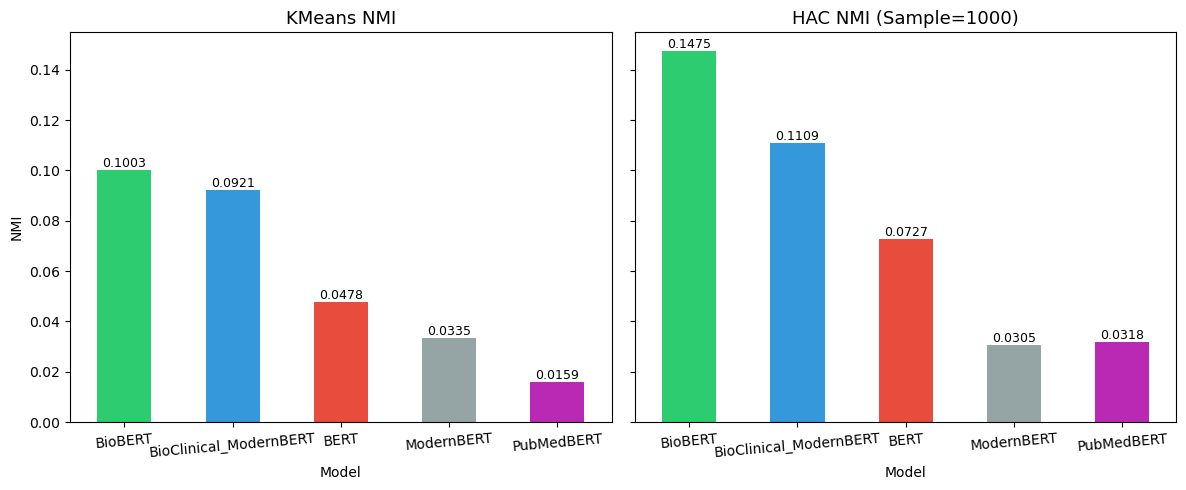

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# KMeans plot
summary_df.set_index("Model")["KMeans_NMI"].plot(kind="bar",ax=axes[0], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[0].set_title("KMeans NMI", fontsize=13)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("NMI")
axes[0].tick_params(axis="x", rotation=5)

for i in axes[0].containers:
    axes[0].bar_label(i, fontsize=9)

# HAC plot
summary_df.set_index("Model")["HAC_NMI"].plot(kind="bar",ax=axes[1], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[1].set_title("HAC NMI (Sample=1000)", fontsize=13)
axes[1].set_xlabel("Model")
axes[1].set_ylabel("NMI")
axes[1].tick_params(axis="x", rotation=5)

for i in axes[1].containers:
    axes[1].bar_label(i, fontsize=9)

plt.tight_layout()
plt.show()

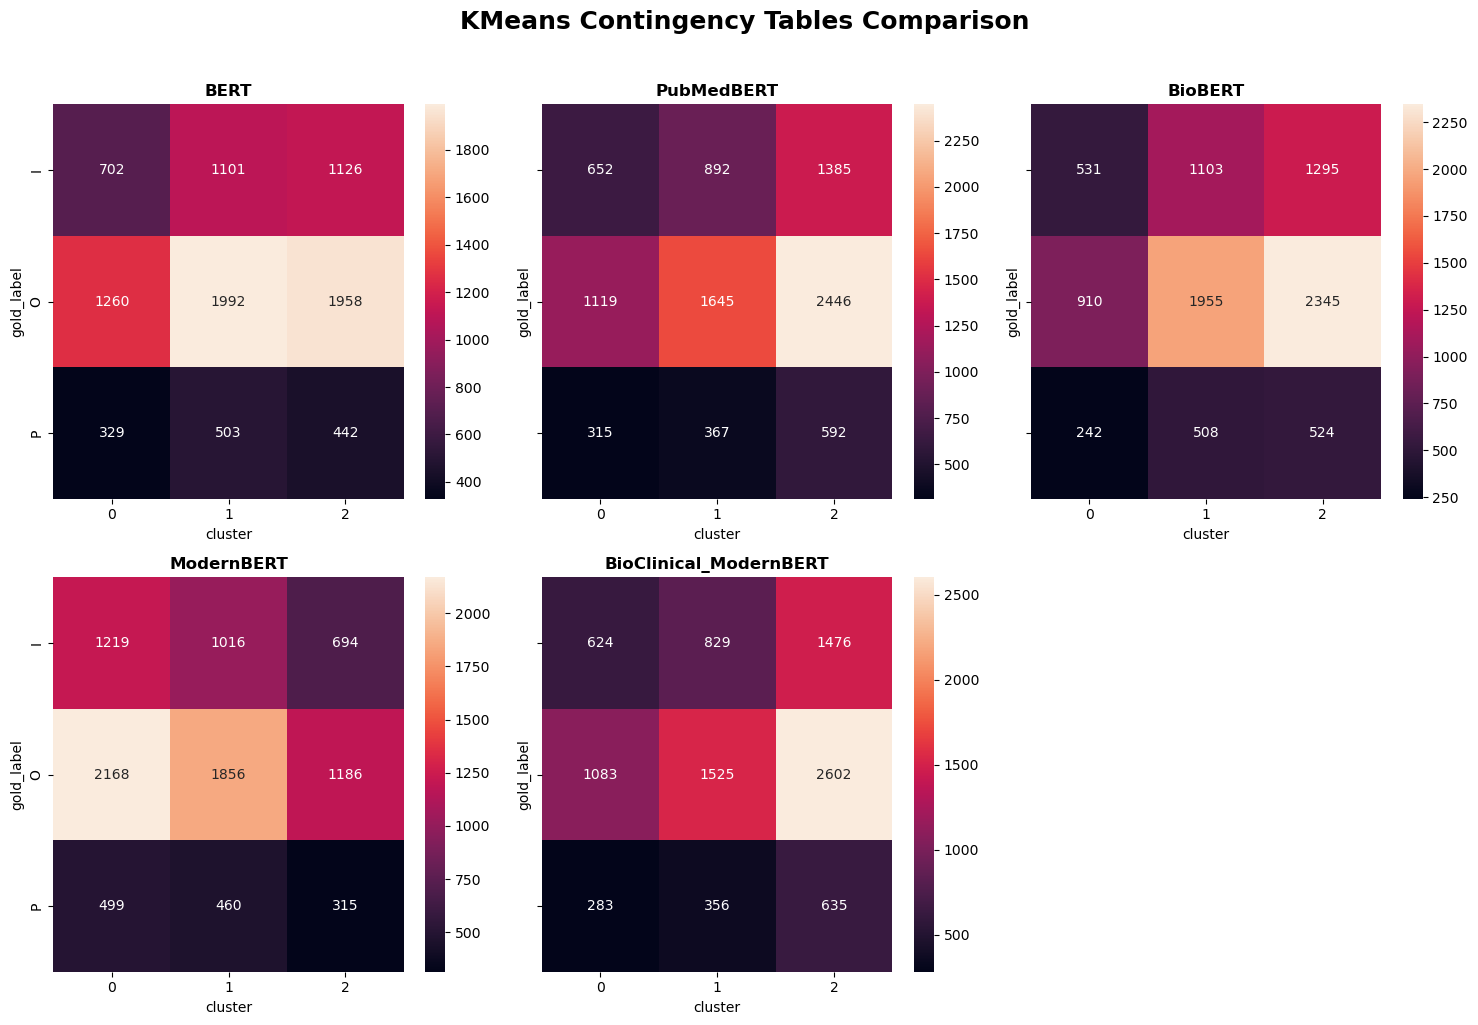

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("KMeans Contingency Tables Comparison", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["KMeans_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


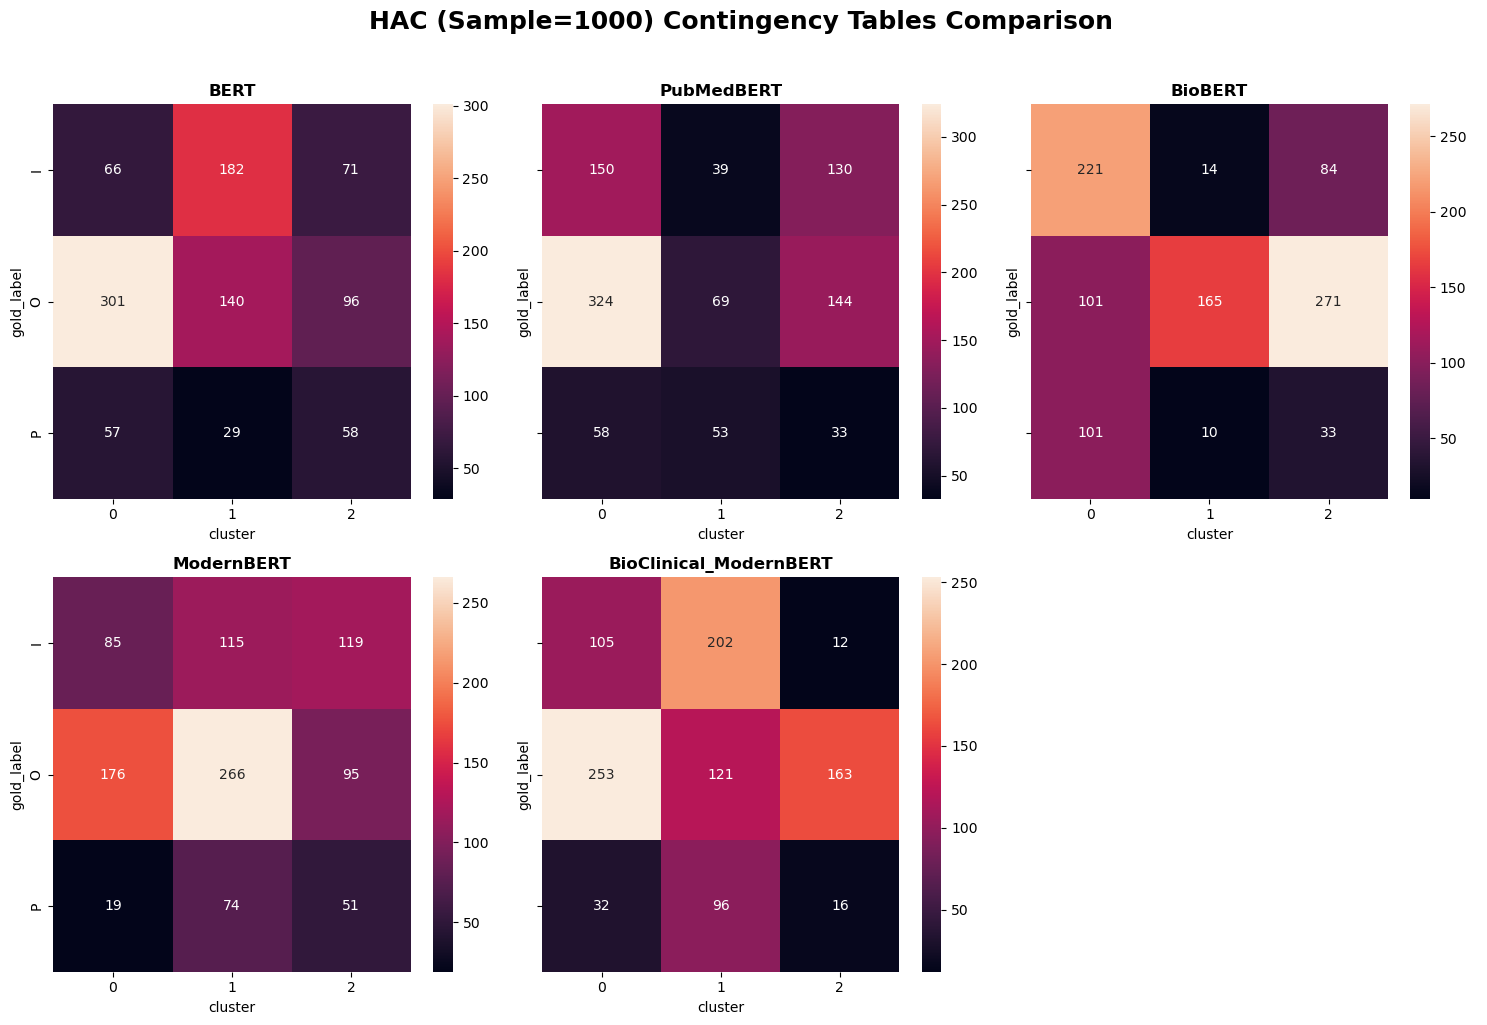

In [110]:
fig, axes = plt.subplots(2, 3, figsize=(15,10), sharey=True)
fig.suptitle("HAC (Sample=1000) Contingency Tables Comparison ", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

sns.heatmap(result_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[0])
axes[0].set_title("BERT",fontweight='bold')

sns.heatmap(result_pub["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[1])
axes[1].set_title("PubMedBERT",fontweight='bold')

sns.heatmap(result_bio["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[2])
axes[2].set_title("BioBERT",fontweight='bold')

sns.heatmap(result_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[3])
axes[3].set_title("ModernBERT",fontweight='bold')

sns.heatmap(result_biocli_mod_bert["HAC_Contingency_Tables"], annot=True, fmt="d", ax=axes[4])
axes[4].set_title("BioClinical_ModernBERT",fontweight='bold')

axes[5].axis('off')

plt.tight_layout()
plt.show()


Even with domain specific encoders (BioBERT,PubMedBERT BioClinical ModernBERT), clusters are not clearly separated by P/I/O. This is expected because P/I/O labels reflect the role of a sentence (participant/intervention/outcome) rather than topical similarity, and sentence embeddings tend to organize texts primarily by semantic topic and writing style. As a result, large mixed clusters emerge, especially under class imbalance (Outcomes dominating and Participants being sparse). This motivates moving from unsupervised clustering to task-specific fine-tuning for more reliable P/I/O discrimination.

#### C) Embedding labels with supervised models (Sentence and Token-Level Fine-Tuned BioBERT and PubMedBERT)

In [111]:
# !pip install evaluate
# !pip install seqeval
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
)
import evaluate
seqeval = evaluate.load("seqeval")

import os
import torch

from transformers.trainer_utils import get_last_checkpoint
from datasets import disable_progress_bar
disable_progress_bar()

os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

In [112]:
# Sentence-level fine-tuning

# Prepare dataset for evaluation
eval_sentence_dataset = sentence_test_records_df[["doc_id","sentence_text"]].copy().dropna().reset_index(drop=True)

# Prepare P/I/O dataset (sentence classification)
train_df = train_pio[["sentence_text", "gold_label"]].copy()
test_df  = test_pio[["sentence_text", "gold_label"]].copy()

le = LabelEncoder()
train_df["label_id"] = le.fit_transform(train_df["gold_label"])
test_df["label_id"]  = le.transform(test_df["gold_label"])

X_train, X_val, y_train, y_val = train_test_split(
    train_df["sentence_text"].tolist(),
    train_df["label_id"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df["label_id"],
)

X_test = test_df["sentence_text"].tolist()
y_test = test_df["label_id"].tolist()

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Sizes:", len(X_train), len(X_val), len(X_test))

# Fine-Tuning Models
MODELS_FT = {
    "BioBERT": "dmis-lab/biobert-base-cased-v1.2",
    "PubMedBERT": "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
}

# Metrics for sentence classification
acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "macro_f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

def make_sentence_datasets(tokenizer, max_len=64):

    # Train, Validation, test dataset
    train_dataset = Dataset.from_dict({"text": X_train, "labels": y_train})
    val_dataset   = Dataset.from_dict({"text": X_val,   "labels": y_val})
    test_dataset  = Dataset.from_dict({"text": X_test,  "labels": y_test})
 
    # Evaluation dataset for final evaluation
    pred_dataset = Dataset.from_dict({"text": eval_sentence_dataset["sentence_text"].tolist()})


    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=max_len)
        

    train_dataset = train_dataset.map(tokenize, batched=True)
    val_dataset   = val_dataset.map(tokenize, batched=True)
    test_dataset  = test_dataset.map(tokenize, batched=True)

    pred_dataset = pred_dataset.map(tokenize, batched=True)


    cols = ["input_ids", "attention_mask", "labels"]
    train_dataset.set_format(type="torch", columns=cols)
    val_dataset.set_format(type="torch", columns=cols)
    test_dataset.set_format(type="torch", columns=cols)

    pred_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])


    return train_dataset, val_dataset, test_dataset, eval_sentence_dataset, pred_dataset


Label mapping: {'I': np.int64(0), 'O': np.int64(1), 'P': np.int64(2)}
Sizes: 15567 3892 846


In [113]:
# Sentence-level fine-tuning

os.makedirs("../outputs/Axis1B/finetune_axis1B", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)
all_sentence_results = []

def run_finetuning(tag, verbose=True, export_eval_csv=True):
    model_name = MODELS_FT[tag]
    output_dir = f"../outputs/Axis1B/finetune_axis1B/{tag}"

    print("\n===========================================")
    print("P/I/O only Fine-tuning results:", tag)
    print("===========================================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Create or check for existing dataset
    train_dataset, val_dataset, test_dataset, eval_df, pred_dataset = make_sentence_datasets(tokenizer, max_len=64)

    last_checkpoint = get_last_checkpoint(output_dir)
    is_trained = last_checkpoint is not None or os.path.exists(os.path.join(output_dir, "config.json"))

    if is_trained:
        load_path = last_checkpoint if last_checkpoint else output_dir
        model = AutoModelForSequenceClassification.from_pretrained(load_path)

# Fine-tune with Trainer
    else:
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(le.classes_))

    args = TrainingArguments(
        output_dir=f"../outputs/Axis1B/finetune_axis1B/{tag}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        gradient_checkpointing=True,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1, 
        dataloader_pin_memory=False,
        disable_tqdm=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    if not is_trained:
        trainer.train()
        trainer.save_model(output_dir)
        
# Evaluate on test set
    test_metrics = trainer.evaluate(test_dataset)

    if verbose:
            print("Test metrics:", test_metrics)

    result = {"Model": tag, **test_metrics}
    all_sentence_results.append(result)

    if export_eval_csv:
        pred = trainer.predict(pred_dataset)
        out_path = f"../outputs/axis1B_{tag}_pred.csv"
        export_pred_csv(eval_df, pred.predictions, le, out_path, sep=";")

    return trainer, test_dataset, result


def export_pred_csv(eval_df, pred_logits, label_encoder, out_path, sep=";"):
    pred_id = np.argmax(pred_logits, axis=-1)
    pred_label = label_encoder.inverse_transform(pred_id)
    
    df = eval_df.copy()
    df["pred_label"] = pred_label

    grouped = (
        df.groupby(["doc_id", "pred_label"])["sentence_text"]
          .apply(lambda x: sep.join(x.tolist()))
          .unstack(fill_value="")
          .reset_index()
    )

    out = pd.DataFrame({
        "doc_id": grouped["doc_id"],
        "participants_pred": grouped["P"] if "P" in grouped.columns else "",
        "interventions_pred": grouped["I"] if "I" in grouped.columns else "",
        "outcomes_pred": grouped["O"] if "O" in grouped.columns else "",
    }).fillna("")


    out.to_csv(out_path, index=False)
    return out


In [114]:
# Token-level fine-tuning

LABEL_MAPPING = {"O": 0, "B": 1, "I": 2}
ID_MAPPING = {0: "O", 1: "B", 2: "I"}

def ensure_list(x):
    return eval(x) if isinstance(x, str) else x

# Prepare dataset for evaluation
eval_token_dataset = sentence_test_records_df[["doc_id","sentence_id","sentence_tokens","p_bio","i_bio","o_bio"]].copy().dropna().reset_index(drop=True)

# Prepare P/I/O dataset (sentence classification)
train_token_df = sentence_records_df[["doc_id","sentence_id","sentence_tokens","p_bio","i_bio","o_bio"]].copy()
test_token_df  = sentence_test_records_df[["doc_id","sentence_id","sentence_tokens","p_bio","i_bio","o_bio"]].copy()


X_token_train, X_token_val= train_test_split(train_token_df, test_size=0.2, random_state=42)


In [115]:
# Dataset builder (subword alignment)
def make_token_datasets(df, tokenizer, bio_col, max_len=64, include_labels=True):

    rows = []
    for r in df.to_dict("records"):
        tokens = ensure_list(r["sentence_tokens"])
        enc = tokenizer(
            tokens,
            is_split_into_words=True,
            truncation=True,
            padding="max_length",
            max_length=max_len,
        )

        if include_labels:
            bio = ensure_list(r[bio_col])
            word_ids = enc.word_ids()

            aligned = []
            prev_w = None
            for w in word_ids:
                if w is None:
                    aligned.append(-100)
                else:
                    lab = bio[w]
                    if w != prev_w:
                        aligned.append(LABEL_MAPPING[lab])
                    else:
                        aligned.append(LABEL_MAPPING["I"] if lab == "B" else LABEL_MAPPING[lab])
                prev_w = w

            enc["labels"] = aligned

        rows.append(enc)

    token_dataset = Dataset.from_list(rows)

    if include_labels:
        token_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    else:
        token_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

    return token_dataset

In [116]:
# Metrics + exporter

from nltk.tokenize.treebank import TreebankWordDetokenizer

# Metrics for token classification
def compute_metrics_token(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_labels, true_preds = [], []
    for p, l in zip(preds, labels):
        sent_l, sent_p = [], []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            sent_l.append(ID_MAPPING[int(li)])
            sent_p.append(ID_MAPPING[int(pi)])
        true_labels.append(sent_l)
        true_preds.append(sent_p)

    scores = seqeval.compute(predictions=true_preds, references=true_labels)
    return {"precision": scores["overall_precision"],
            "recall": scores["overall_recall"],
            "f1": scores["overall_f1"]}



# detokenize 
untoken = TreebankWordDetokenizer()

def untokenize_tokens(tokens):
    return untoken.detokenize(tokens)

# BIO logits -> doc-level span text (ONE field) 
def extract_spans_to_doc(eval_df, pred_logits, out_col, sep="; "):
    """
    eval_df must have columns: ["doc_id","sentence_tokens"] in SAME ROW ORDER as pred_logits
    pred_logits: (N, seq_len, 3) BIO logits
    out_col: output column name in returned df
    """
    pred_ids = np.argmax(pred_logits, axis=-1)  # (N, L)
    rows = []

    for (doc_id, toks), ids in zip(eval_df[["doc_id","sentence_tokens"]].values, pred_ids):
        toks = eval(toks) if isinstance(toks, str) else toks
        ids = ids[:len(toks)]  # truncate to token length

        # BIO -> spans
        spans, s = [], None
        for i, t in enumerate(ids):
            if t == 1:  # B
                if s is not None:
                    spans.append((s, i))
                s = i
            elif t == 0 and s is not None:  # O closes
                spans.append((s, i))
                s = None
        if s is not None:
            spans.append((s, len(ids)))

        # spans -> text (use your detokenizer)
        txt = sep.join(untokenize_tokens(toks[a:b]) for a, b in spans)
        rows.append((doc_id, txt))

    out = pd.DataFrame(rows, columns=["doc_id", out_col])

    # doc-level concat across sentences (skip empty)
    out = (
        out.groupby("doc_id")[out_col]
           .apply(lambda xs: sep.join([x for x in xs.tolist() if x]))
           .reset_index()
    )
    return out

# Merge doc-level outputs -> final CSV
def export_doc_to_pio(eval_df, predP, predI, predO, out_path, sep="; "):
    """
    predP/predI/predO: (N, seq_len, 3) logits from P/I/O token taggers
    eval_df: columns ["doc_id","sentence_tokens"] aligned with those predictions
    """
    P = extract_spans_to_doc(eval_df, predP, "participants_pred", sep=sep)
    I = extract_spans_to_doc(eval_df, predI, "interventions_pred", sep=sep)
    O = extract_spans_to_doc(eval_df, predO, "outcomes_pred", sep=sep)

    out = P.merge(I, on="doc_id", how="outer").merge(O, on="doc_id", how="outer").fillna("")
    out.to_csv(out_path, index=False)
    print("Saved:", out_path, out.shape, "| docs:", out["doc_id"].nunique())
    return out


In [121]:
# Token-level fine-tuning

all_token_results = []

# one-field trainer (P or I or O)
def run_token_finetuning_one_field(tag, bio_col, verbose=True, export_eval_csv=True):
    model_name = MODELS_FT[tag]
    output_dir = f"../outputs/Axis1B/finetune_axis1B/{tag}_{bio_col}"
    os.makedirs(output_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    eval_token_df = test_token_df[["doc_id","sentence_id","sentence_tokens"]].dropna().reset_index(drop=True)
    
# Create or check for existing dataset
    train_token_dataset = make_token_datasets(X_token_train, tokenizer, bio_col, max_len=64, include_labels=True)
    val_token_dataset = make_token_datasets(X_token_val,   tokenizer, bio_col, max_len=64, include_labels=True)
    test_token_dataset = make_token_datasets(test_token_df, tokenizer, bio_col, max_len=64, include_labels=True)
    pred_token_dataset = make_token_datasets(eval_token_df, tokenizer, bio_col, max_len=64, include_labels=False)

# load or init model
    last_checkpoint = get_last_checkpoint(output_dir)
    is_trained = last_checkpoint is not None or os.path.exists(os.path.join(output_dir, "config.json"))

    if is_trained:
        load_path = last_checkpoint if last_checkpoint else output_dir
        model = AutoModelForTokenClassification.from_pretrained(load_path)

# Fine-tune with Trainer
    else:
        model = AutoModelForTokenClassification.from_pretrained(model_name, num_labels=3, id2label=ID_MAPPING, label2id=LABEL_MAPPING)
   

    args = TrainingArguments(
        output_dir=f"../outputs/Axis1B/finetune_axis1B/{tag}_{bio_col}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        gradient_checkpointing=True,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1, 
        dataloader_pin_memory=False,
        disable_tqdm=True,
        report_to="none",
    )

    trainer = Trainer(model=model, 
                      args=args, 
                      train_dataset=train_token_dataset, 
                      eval_dataset=val_token_dataset,
                      processing_class=tokenizer, 
                      compute_metrics=compute_metrics_token,
    )
    
    if not is_trained:
        trainer.train()
        trainer.save_model(output_dir)
        
# Evaluate on test set
    test_metrics = trainer.evaluate(test_token_dataset)

    if verbose:
            print("Test metrics:", test_metrics)

    result = {"Model": tag, **test_metrics}
    all_token_results.append(result)

    pred_logits = trainer.predict(pred_token_dataset).predictions

    return eval_token_df, pred_logits, test_metrics


def run_token_finetuning(tag, verbose=False, sep="; "):

    print("\n===========================================")
    print("Token-level Fine-tuning results:", tag)
    print("===========================================")

    eval_token_df_p, pred_p, met_p = run_token_finetuning_one_field(tag, "p_bio", verbose=verbose)
    eval_token_df_i, pred_i, met_i = run_token_finetuning_one_field(tag, "i_bio", verbose=verbose)
    eval_token_df_o, pred_o, met_o = run_token_finetuning_one_field(tag, "o_bio", verbose=verbose)

    assert eval_token_df_p.shape[0] == eval_token_df_i.shape[0] == eval_token_df_o.shape[0]

    out_path = f"../outputs/axis1B_{tag}_pred.csv"

    out_df = export_doc_to_pio(
        eval_df = eval_token_df_p[["doc_id","sentence_tokens"]].copy(),
        predP=pred_p, predI=pred_i, predO=pred_o,
        out_path=out_path,
        sep=sep
    )

    result = {
        "Model": tag,
        "P_test": met_p,
        "I_test": met_i,
        "O_test": met_o,
        "out_path": out_path
    }
    return result, out_df

In [122]:
all_sentence_results = []
trainer_bio, test_dataset_bio, result_ft_bio = run_finetuning("BioBERT",verbose=False)
trainer_pub, test_dataset_pub, result_ft_pub = run_finetuning("PubMedBERT", verbose=False)


P/I/O only Fine-tuning results: BioBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'eval_loss': '0.451', 'eval_model_preparation_time': '0.0009', 'eval_accuracy': '0.8641', 'eval_macro_f1': '0.8597', 'eval_runtime': '5.025', 'eval_samples_per_second': '168.4', 'eval_steps_per_second': '42.19'}

P/I/O only Fine-tuning results: PubMedBERT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'eval_loss': '0.4359', 'eval_model_preparation_time': '0.0011', 'eval_accuracy': '0.8818', 'eval_macro_f1': '0.8752', 'eval_runtime': '4.945', 'eval_samples_per_second': '171.1', 'eval_steps_per_second': '42.87'}


In [123]:
all_token_results = []
result_tok_bio, pred_df_tok_bio = run_token_finetuning("BioBERT", verbose=False, sep="; ")
result_tok_pub, pred_df_tok_pub = run_token_finetuning("PubMedBERT", verbose=False, sep="; ")


Token-level Fine-tuning results: BioBERT


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

{'loss': '0.5636', 'grad_norm': '2.603', 'learning_rate': '1.988e-05', 'epoch': '0.01177'}
{'loss': '0.313', 'grad_norm': '1.423', 'learning_rate': '1.977e-05', 'epoch': '0.02354'}
{'loss': '0.2723', 'grad_norm': '0.6596', 'learning_rate': '1.965e-05', 'epoch': '0.03531'}
{'loss': '0.2629', 'grad_norm': '0.889', 'learning_rate': '1.953e-05', 'epoch': '0.04708'}
{'loss': '0.296', 'grad_norm': '2.182', 'learning_rate': '1.941e-05', 'epoch': '0.05885'}
{'loss': '0.2961', 'grad_norm': '0.4003', 'learning_rate': '1.93e-05', 'epoch': '0.07062'}
{'loss': '0.2896', 'grad_norm': '0.3435', 'learning_rate': '1.918e-05', 'epoch': '0.08239'}
{'loss': '0.2949', 'grad_norm': '0.7687', 'learning_rate': '1.906e-05', 'epoch': '0.09416'}
{'loss': '0.272', 'grad_norm': '0.734', 'learning_rate': '1.894e-05', 'epoch': '0.1059'}
{'loss': '0.2504', 'grad_norm': '0.9226', 'learning_rate': '1.883e-05', 'epoch': '0.1177'}
{'loss': '0.2239', 'grad_norm': '1.242', 'learning_rate': '1.871e-05', 'epoch': '0.1295'}
{

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'train_runtime': '3470', 'train_samples_per_second': '19.59', 'train_steps_per_second': '2.448', 'train_loss': '0.3287', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.1372', 'eval_precision': '0.3971', 'eval_recall': '0.4538', 'eval_f1': '0.4235', 'eval_runtime': '14.83', 'eval_samples_per_second': '132.1', 'eval_steps_per_second': '33.03', 'epoch': '2'}
Saved: ../outputs/axis1B_PubMedBERT_pred.csv (178, 4) | docs: 178


In [124]:
# summary table
summary_df = pd.DataFrame(all_sentence_results)[
    ["Model", "eval_loss", "eval_accuracy", "eval_macro_f1"] # Runtime-related values in this table reflect test-set evaluation time after loading saved checkpoints, rather than full training time. Therefore, they are not used for the main comparison of model efficiency.
].rename(columns={
    "eval_loss": "Loss",
    "eval_accuracy": "Accuracy",
    "eval_macro_f1": "Macro-F1"
})
summary_df

,Model,Loss,Accuracy,Macro-F1
0,BioBERT,0.450968,0.864066,0.859665
1,PubMedBERT,0.435948,0.881797,0.875216


In [ ]:
# Classification report and Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred = trainer_pub.predict(test_dataset_pub)
y_pred = np.argmax(pred.predictions, axis=-1)

print("\nClassification report for BioBERT:")
print(classification_report(pred.label_ids, y_pred, target_names=le.classes_))

print("\nConfusion matrix for BioBERT:")
print(confusion_matrix(pred.label_ids, y_pred))

pred = trainer_bio.predict(test_dataset_bio)
y_pred = np.argmax(pred.predictions, axis=-1)

print("\n\n\nClassification report for PubMedBERT:")
print(classification_report(pred.label_ids, y_pred, target_names=le.classes_))
print("\nConfusion matrix for PubMedBERT:")
print(confusion_matrix(pred.label_ids, y_pred))


Classification report for BioBERT:
              precision    recall  f1-score   support

           I       0.91      0.78      0.84       289
           O       0.87      0.95      0.91       431
           P       0.86      0.90      0.88       126

    accuracy                           0.88       846
   macro avg       0.88      0.87      0.88       846
weighted avg       0.88      0.88      0.88       846


Confusion matrix for BioBERT:
[[224  53  12]
 [ 16 409   6]
 [  6   7 113]]



Classification report for PubMedBERT:
              precision    recall  f1-score   support

           I       0.86      0.78      0.82       289
           O       0.86      0.92      0.89       431
           P       0.86      0.88      0.87       126

    accuracy                           0.86       846
   macro avg       0.86      0.86      0.86       846
weighted avg       0.86      0.86      0.86       846


Confusion matrix for PubMedBERT:
[[224  56   9]
 [ 26 396   9]
 [  9   6 111]]
